In [38]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [40]:
query = """
SELECT uid, timestamp
FROM checker
WHERE uid NOT LIKE 'admin_%'
    AND labname = 'project1'
    AND status = 'ready'
    AND timestamp IS NOT NULL
ORDER BY timestamp
"""
df = pd.io.sql.read_sql(query, conn)

In [41]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = df['timestamp'].dt.date
daily = df.groupby(['date', 'uid']).size().reset_index(name='count')
daily = daily.sort_values(['uid', 'date'])
daily['cumulative'] = daily.groupby('uid')['count'].cumsum()

In [42]:
date_range = pd.date_range(start=daily['date'].min(), end=daily['date'].max(), freq='D')
users = daily['uid'].unique()
idx = pd.MultiIndex.from_product([date_range.date, users], names=['date', 'uid'])
full = daily.set_index(['date', 'uid']).reindex(idx).fillna(0)
full['cumulative'] = full.groupby('uid')['count'].cumsum()
full = full.reset_index()

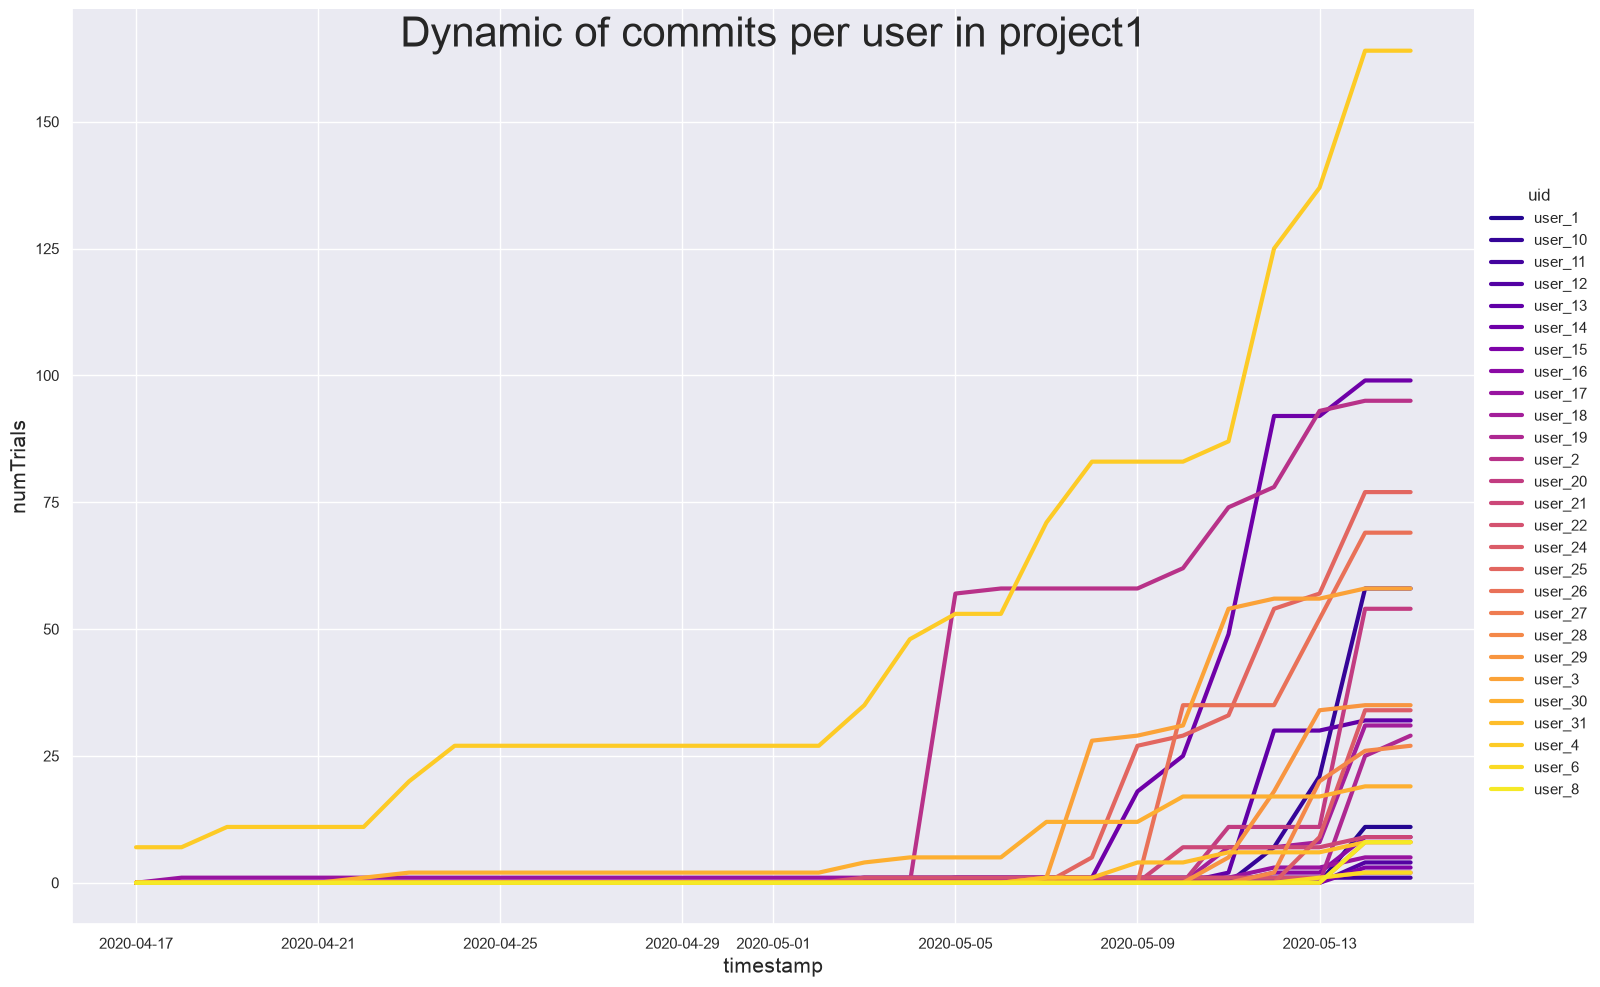

In [46]:
sns.set_theme(style='darkgrid')
g = sns.relplot(
    data=full,
    x='date', y='cumulative', hue='uid',
    kind='line', linewidth=3,
    height=10, aspect=1.5,
    palette='plasma',
    legend=True
)
g.ax.set_title('Dynamic of commits per user in project1', fontsize=30, y=0.95)
g.ax.set_xlabel('timestamp', fontsize=15)
g.ax.set_ylabel('numTrials', fontsize=15)
plt.show()

In [44]:
conn.close()

Какой пользователь почти всё время был лидером по числу коммитов?

Ответ: user_4

Какой пользователь был лидером лишь недолгое время?

Ответ: user_2